In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(ggstatsplot)
library(cowplot)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ───────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


You can cite this package as:mute───────────────────────────────────────────────────────

In [2]:
taxa_tab <-  read.table("/ceph/projects/010_SweMaMi/bm.nowak/data/tp2_taxa_fp_sp__42_250909.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote = '"')
head(taxa_tab)

,100000112243,100000133958,100000418123,100000168325,100000129494,100000126820,100000123362,100000126714,100000421192,100000427415,⋯,100000426050,100000433645,100000106303,100000106341,100000103470,100000106136,100000108482,100000157503,100000148082,100000148693
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Acidaminococcus intestini,0.00000,1.32773,0.00000,0,0,0.00000,0,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0.00000,0e+00,0.00000,0.00000,0.00000,0.00000,0.0000
Acinetobacter SGB65105,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0.00000,0e+00,0.00000,0.00000,0.05408,0.00000,0.0000
Actinobaculum sp_oral_taxon_183,0.00000,0.00000,0.00000,0,0,0.00010,0,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0.00000,0e+00,0.00000,0.00000,0.00000,0.00000,0.0000
Actinomyces bouchesdurhonensis,0.00000,0.00000,0.00000,0,0,0.00674,0,0.00000,0.00000,0.00073,⋯,0,0.00000,0.00000,0.00188,7e-05,0.00000,0.00492,0.00222,0.00059,0.0000
Actinomyces graevenitzii,0.00211,0.00000,0.00203,0,0,0.00000,0,0.00279,0.00143,0.00254,⋯,0,0.00695,0.00094,0.00045,0e+00,0.00093,0.00036,0.00000,0.00032,0.0011
Actinomyces naeslundii,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,0.00234,⋯,0,0.00258,0.00000,0.00000,0e+00,0.00000,0.00000,0.00000,0.00000,0.0000


In [3]:
dim(taxa_tab)

[1] 984  42

In [4]:
colnames(taxa_tab)

[1] "100000112243" "100000133958" "100000418123" "100000168325" "100000129494"
 [6] "100000126820" "100000123362" "100000126714" "100000421192" "100000427415"
[11] "100000426753" "100000433799" "100000406809" "100000136430" "100000140093"
[16] "100000144381" "100000417232" "100000189313" "100000185766" "100000155653"
[21] "100000172865" "100000408391" "100000134894" "100000420362" "100000172728"
[26] "100000186718" "100000426708" "100000422069" "100000429761" "100000434772"
[31] "100000424926" "100000421864" "100000426050" "100000433645" "100000106303"
[36] "100000106341" "100000103470" "100000106136" "100000108482" "100000157503"
[41] "100000148082" "100000148693"

In [5]:
taxa_tab[,1]

[1] 0.00000 0.00000 0.00000 0.00000 0.00211 0.00000 0.00082 0.00000 0.00247
 [10] 0.00000 0.00000 0.00000 0.00000 0.00330 0.00128 0.00000 0.00000 0.09491
 [19] 0.24905 0.00000 0.00000 0.01668 0.00000 0.06192 0.00261 0.00000 0.03222
 [28] 0.83274 0.00000 0.15475 0.04954 0.01291 0.00000 0.00000 0.00000 0.68430
 [37] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00182 0.00000 0.00000 0.00000
 [46] 0.00000 0.00988 0.00000 1.40008 0.00000 0.13543 0.00000 0.00000 0.00002
 [55] 0.00000 0.00000 0.00000 0.16199 0.00000 0.00000 0.00000 0.00000 0.00000
 [64] 0.42627 0.03012 0.00000 0.21209 0.00000 0.00000 0.00000 0.00000 0.16679
 [73] 0.83203 0.15895 0.21922 0.04272 0.00000 0.00000 0.00000 0.00000 0.00000
 [82] 0.14059 0.36992 0.00000 0.04758 0.00000 0.00000 0.00000 2.13139 0.04280
 [91] 0.00000 0.67712 1.47075 0.51865 0.00000 0.00000 0.00000 0.04459 0.00000
[100] 0.00000 0.02451 0.01013 0.00000 4.08171 0.02241 0.21688 0.00000 0.00000
[109] 0.00000 0.01456 0.00000 0.04569 0.00000 0.00000 0.00000 0.00000 0.00000
[118] 0.00000 0.00000 0.00000 0.00037 0.00000 0.19019 0.00000 0.00000 0.39673
[127] 0.00000 0.00000 0.00000 0.00072 0.00000 0.00000 0.00000 0.00000 0.00000
[136] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000
[145] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00027 0.00000 0.00000
[154] 0.00000 0.00000 0.00000 0.57011 0.29381 0.00000 0.00000 0.20067 0.05368
[163] 0.27433 0.00000 0.00000 0.00000 0.00000 0.11848 0.03935 0.00000 0.00000
[172] 0.00000 0.00000 2.11493 0.00000 0.00000 0.00037 0.00000 0.00000 0.00000
[181] 0.03669 0.00000 0.00000 0.12084 0.00081 0.00000 0.11135 0.00000 0.00000
[190] 0.03541 0.02868 0.00000 0.00000 0.00000 0.00000 1.32703 0.00000 0.00000
[199] 0.02398 0.08461 0.02595 0.00000 0.00000 0.00000 0.54841 0.15020 0.12947
[208] 0.00000 0.31158 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.72528
[217] 0.00000 0.13539 0.00000 0.02276 0.00722 0.00000 0.00195 0.00000 0.00000
[226] 0.00000 0.00000 0.34058 0.39094 1.84077 0.33800 0.00000 0.00000 0.00000
[235] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000
[244] 0.00000 0.00000 0.00000 0.00000 0.00000 0.23788 0.80395 0.06325 0.18417
[253] 0.00000 0.00000 0.10499 0.00200 0.02072 0.00055 0.00000 0.00000 0.05634
[262] 0.00000 0.00000 0.00000 0.00205 0.00000 0.00000 0.00000 0.00000 0.00000
[271] 0.00000 0.00000 0.00748 0.00000 0.00962 0.72264 0.00000 0.00000 0.03260
[280] 0.00000 0.50811 3.13127 0.00000 0.09947 0.00000 0.01399 0.00000 0.06583
[289] 0.35473 0.12613 0.00000 0.00000 0.12277 1.12393 8.28920 0.84490 1.01027
[298] 0.00000 0.46571 0.00000 0.00000 0.00000 0.00000 0.00000 0.41691 0.00408
[307] 0.00000 0.00036 1.68488 0.00000 1.74642 0.00000 0.06918 0.00000 0.00000
[316] 3.67518 0.00910 0.00205 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000
[325] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00660 0.00000 0.00000 0.00000
[334] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00075 0.00066 0.00202 0.00000
[343] 0.00000 0.03125 0.00000 0.00000 0.00000 0.01113 0.01137 0.00000 0.00000
[352] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000
[361] 0.00000 0.31815 0.03413 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000
[370] 0.00000 0.00000 0.00000 0.00000 0.00000 1.07009 0.00000 0.00000 0.00000
[379] 1.21367 0.00000 0.00000 0.00000 0.02913 0.00000 0.04020 0.00000 0.00000
[388] 0.00000 0.00000 0.00000 0.16312 0.02067 0.00461 0.00000 0.00000 0.00000
[397] 0.00000 0.00000 0.00000 0.31943 0.00000 0.00978 0.00000 0.00000 0.00000
[406] 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.23838 0.00000 0.00000
[415] 0.00000 0.00445 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000 0.00000
[424] 0.00000 0.00000 0.00000 0.00000 0.00868 0.00000 0.11392 0.00000 0.00000
[433] 0.00000 0.00000 0.14099 0.00000 0.00348 0.00000 0.00000 0.01836 0.00055
[442] 0.00000 0.00000 0.00000 0.00000 0.03925 0.00000 0.00000 0.00000 0.00000
[451] 0.00000 0.00276 0.00000 0.00000 0.00000 0.00000 0.87182 0.00000 0.00000
[460] 0.00000 0.01178 0.

In [6]:
row.names(taxa_tab)

[1] "Acidaminococcus intestini"                                     
  [2] "Acinetobacter SGB65105"                                        
  [3] "Actinobaculum sp_oral_taxon_183"                               
  [4] "Actinomyces bouchesdurhonensis"                                
  [5] "Actinomyces graevenitzii"                                      
  [6] "Actinomyces naeslundii"                                        
  [7] "Actinomyces oris"                                              
  [8] "Actinomyces SGB17132"                                          
  [9] "Actinomyces SGB17154"                                          
 [10] "Actinomyces SGB17157"                                          
 [11] "Actinomyces SGB17163"                                          
 [12] "Actinomyces SGB17168"                                          
 [13] "Actinomyces sp_HMSC035G02"                                     
 [14] "Actinomyces sp_ICM47"                                          
 [15] "Actinomyces sp_ICM58"                                          
 [16] "Actinomyces sp_oral_taxon_448"                                 
 [17] "Actinomyces sp_ph3"                                            
 [18] "Adlercreutzia equolifaciens"                                   
 [19] "Agathobaculum butyriciproducens"                               
 [20] "Akkermansia muciniphila"                                       
 [21] "Alcaligenes SGB14037"                                          
 [22] "Alistipes communis"                                            
 [23] "Alistipes dispar"                                              
 [24] "Alistipes finegoldii"                                          
 [25] "Alistipes ihumii"                                              
 [26] "Alistipes indistinctus"                                        
 [27] "Alistipes onderdonkii"                                         
 [28] "Alistipes putredinis"                                          
 [29] "Alistipes senegalensis"                                        
 [30] "Alistipes shahii"                                              
 [31] "Alistipes sp_AF17_16"                                          
 [32] "Alistipes timonensis"                                          
 [33] "Allisonella histaminiformans"                                  
 [34] "Alloscardovia omnicolens"                                      
 [35] "Alterileibacterium massiliense"                                
 [36] "Anaerobutyricum hallii"                                        
 [37] "Anaerobutyricum soehngenii"                                    
 [38] "Anaerococcus lactolyticus"                                     
 [39] "Anaerococcus obesiensis"                                       
 [40] "Anaerococcus prevotii"                                         
 [41] "Anaerococcus SGB15407"                                         
 [42] "Anaerococcus SGB4342"                                          
 [43] "Anaerococcus SGB6671"                                          
 [44] "Anaerofilum sp_BX8"                                            
 [45] "Anaerofustis stercorihominis"                                  
 [46] "Anaeromassilibacillus sp_An250"                                
 [47] "Anaerosacchariphilus sp_NSJ_68"                                
 [48] "Anaerostipes caccae"                                           
 [49] "Anaerostipes hadrus"                                           
 [50] "Anaerostipes SGB4708"                                          
 [51] "Anaerotignum faecicola"                                        
 [52] "Anaerotruncus colihominis"                                     
 [53] "Anaerotruncus massiliensis"                                    
 [54] "Anaerotruncus rubiinfantis"                                    
 [55] "Angelakisella massiliensis"                                    
 [56] "Bacteria unclassified_SGB54310"                                
 [57] "Bacteroides bouches

In [7]:
tail(taxa_tab)

,100000112243,100000133958,100000418123,100000168325,100000129494,100000126820,100000123362,100000126714,100000421192,100000427415,⋯,100000426050,100000433645,100000106303,100000106341,100000103470,100000106136,100000108482,100000157503,100000148082,100000148693
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Vescimonas SGB15086,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Vescimonas SGB15087,0.00359,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.02664,0.00000,0.00000
Victivallis lenta,0.01133,0.00000,0.00000,0.00000,0.00000,0.02110,0.00000,0.00000,0.00000,0.07131,⋯,0.00036,0.00000,0.00000,0.24265,0.00000,0.00000,0.05986,0.02399,0.00000,0.00000
Victivallis vadensis,0.00000,0.01186,0.00000,0.00000,0.00000,0.00000,0.00000,0.02922,0.00000,0.00816,⋯,0.00128,0.00000,0.00000,0.00000,0.00000,0.00000,0.03990,0.00413,0.18357,0.00000
Waltera intestinalis,0.00387,0.05861,0.00700,0.01722,0.05579,0.00000,0.22885,0.00157,0.08619,3.50011,⋯,0.99393,0.00689,0.01219,0.94727,4.47788,0.02220,1.28550,0.05965,0.02656,0.00211
Other_taxa,2.47230,5.82934,0.86371,0.42482,1.55244,1.72654,1.59920,0.44751,0.70347,2.20868,⋯,0.88001,11.28523,1.17631,0.57416,7.19169,1.02617,1.28246,3.29574,4.33514,1.62319


In [8]:
combined_fp_sp_tp2 <- read.csv("/ceph//projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/2025-09-01_combined_fp_sp_tp2.csv", header = TRUE)
head(combined_fp_sp_tp2)
dim(combined_fp_sp_tp2)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,First pregnancy
3,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
4,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
6,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy


[1]  42 567

In [9]:
# Check that all columns add up to 100
colsum_tp2 <- colSums(taxa_tab)
colsum_tp2
length(colsum_tp2)

100000112243 100000133958 100000418123 100000168325 100000129494 100000126820 
         100          100          100          100          100          100 
100000123362 100000126714 100000421192 100000427415 100000426753 100000433799 
         100          100          100          100          100          100 
100000406809 100000136430 100000140093 100000144381 100000417232 100000189313 
         100          100          100          100          100          100 
100000185766 100000155653 100000172865 100000408391 100000134894 100000420362 
         100          100          100          100          100          100 
100000172728 100000186718 100000426708 100000422069 100000429761 100000434772 
         100          100          100          100          100          100 
100000424926 100000421864 100000426050 100000433645 100000106303 100000106341 
         100          100          100          100          100          100 
100000103470 100000106136 100000108482 100000157503 100000148082 100000148693 
         100          100          100          100          100          100

[1] 42

In [10]:
# Read fp and sp metadata files to obtain barcodes, OBS $Group for FP has a SPACE at the end!!
combined_fp_sp_tp2$Group

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[25] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy"

In [11]:
fp_bc <-  combined_fp_sp_tp2 |>
  filter(Group == "First pregnancy ") |>
  pull(kit2.faecal_sample.barcode)
print(fp_bc)
length(fp_bc)

 [1] 100000144381 100000172865 100000112243 100000168325 100000123362
 [6] 100000106341 100000172728 100000129494 100000106136 100000136430
[11] 100000126714 100000155653 100000133958 100000148082 100000126820
[16] 100000140093 100000134894 100000108482 100000106303 100000148693
[21] 100000103470


[1] 21

In [12]:
sp_bc <-  combined_fp_sp_tp2 |>
  filter(Group == "Second pregnancy") |>
  pull(kit2.faecal_sample.barcode)
print(sp_bc)
length(sp_bc)

 [1] 100000433799 100000426708 100000157503 100000424926 100000189313
 [6] 100000426753 100000422069 100000421192 100000417232 100000420362
[11] 100000408391 100000427415 100000406809 100000421864 100000429761
[16] 100000434772 100000433645 100000426050 100000185766 100000418123
[21] 100000186718


[1] 21

In [13]:
# Save fp and sp in separate df 
fp_taxa <- taxa_tab[, colnames(taxa_tab) %in% fp_bc]
dim(fp_taxa) 

[1] 984  21

In [14]:
sp_taxa <- taxa_tab[, colnames(taxa_tab) %in% sp_bc]
dim(sp_taxa) 

[1] 984  21

 ## Alpha Diversity--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Shannon--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
fp_shan_tp2 <- apply(fp_taxa, 2, diversity, index = "shannon")
fp_shan_tp2

100000112243 100000133958 100000168325 100000129494 100000126820 100000123362 
    4.236528     4.277826     3.803011     3.971679     4.075306     4.105779 
100000126714 100000136430 100000140093 100000144381 100000155653 100000172865 
    4.550494     4.608895     4.404560     4.368467     4.479914     4.011708 
100000134894 100000172728 100000106303 100000106341 100000103470 100000106136 
    4.254005     4.491089     3.865106     4.591458     3.915710     4.120007 
100000108482 100000148082 100000148693 
    3.982267     4.153986     3.157082

In [16]:
summary(fp_shan_tp2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.157   3.982   4.154   4.163   4.405   4.609 

In [17]:
sp_shan_tp2 <- apply(sp_taxa, 2, diversity, index = "shannon")
sp_shan_tp2  

100000418123 100000421192 100000427415 100000426753 100000433799 100000406809 
    3.338456     3.734459     4.287087     4.426498     4.097482     3.984390 
100000417232 100000189313 100000185766 100000408391 100000420362 100000186718 
    4.053310     3.883601     3.904755     4.126145     4.363839     3.830565 
100000426708 100000422069 100000429761 100000434772 100000424926 100000421864 
    4.239678     4.158346     4.134483     4.146937     3.423942     4.423570 
100000426050 100000433645 100000157503 
    3.483158     3.731964     3.999929

In [18]:
summary(sp_shan_tp2)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.338   3.831   4.053   3.989   4.158   4.426 

In [19]:
# Save shannon index into one df
df_shannon <- data.frame(Shannon = c(fp_shan_tp2, sp_shan_tp2), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_shan_tp2), length(sp_shan_tp2))))
df_shannon

,Shannon,Group
,<dbl>,<chr>
100000112243,4.236528,Nulliparous
100000133958,4.277826,Nulliparous
100000168325,3.803011,Nulliparous
100000129494,3.971679,Nulliparous
100000126820,4.075306,Nulliparous
100000123362,4.105779,Nulliparous
100000126714,4.550494,Nulliparous
100000136430,4.608895,Nulliparous
100000140093,4.404560,Nulliparous


In [20]:
# Check that numeric
class(df_shannon$Shannon)

[1] "numeric"

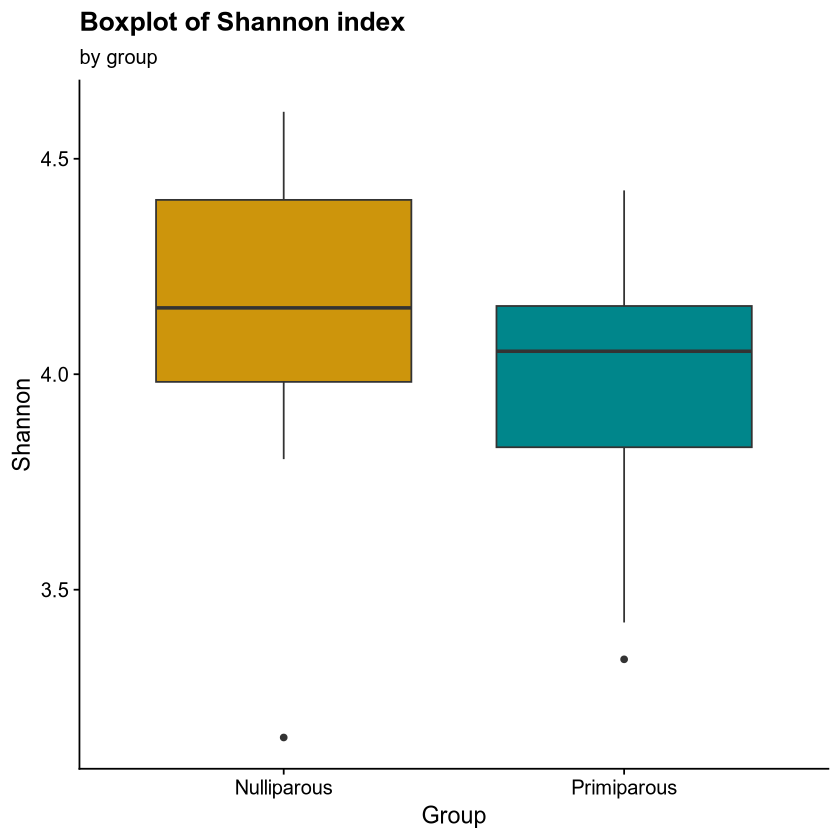

In [21]:
clr_tp2 <- c("Nulliparous" = "darkgoldenrod3" , "Primiparous" = "turquoise4")

# Boxplot
df_shannon |> ggplot(aes(x = Group, y = Shannon, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Shannon",
    title = "Boxplot of Shannon index", 
    subtitle = "by group"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

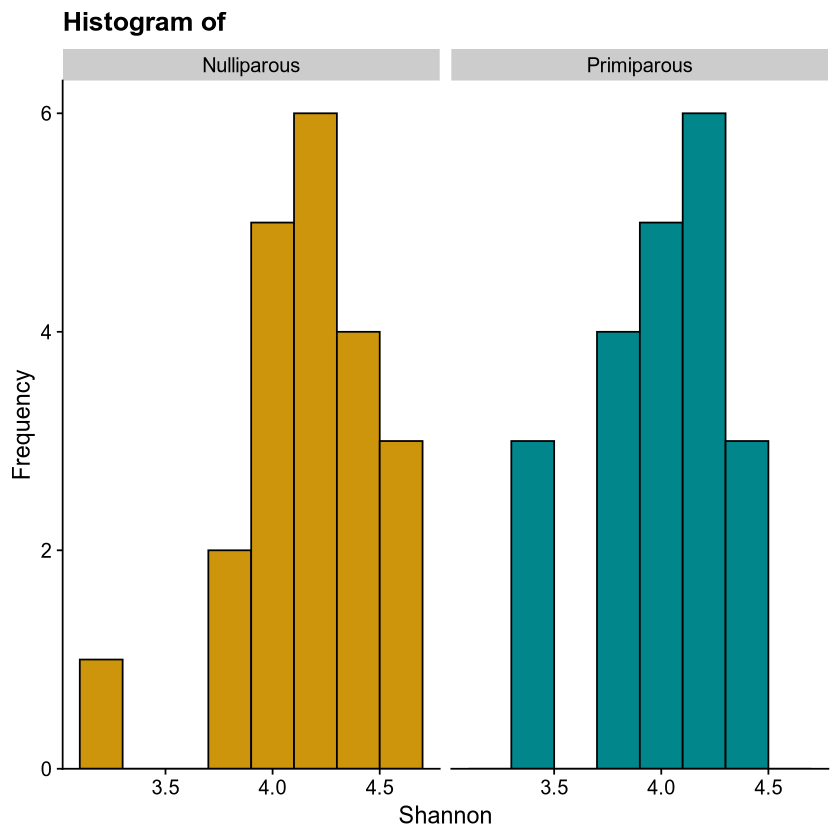

In [22]:
# Histogram
df_shannon |> ggplot(aes(x = Shannon, fill = Group)) +
geom_histogram(binwidth = 0.2, position = "identity", col = "black") + 
scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
labs(
    x = "Shannon",
    y = "Frequency",
    title = "Histogram of "
) +
scale_y_continuous(
    expand = expansion(mult = c(0, 0.05))
  ) + 
theme_half_open() +
facet_wrap(~Group) +
theme(legend.position = "none") 

In [23]:
# after this Primiparous == NA
df_shannon_1 <- df_shannon |>
  rownames_to_column(var = "Sample_ID")
df_shannon_1

Sample_ID,Shannon,Group
<chr>,<dbl>,<chr>
100000112243,4.236528,Nulliparous
100000133958,4.277826,Nulliparous
100000168325,3.803011,Nulliparous
100000129494,3.971679,Nulliparous
100000126820,4.075306,Nulliparous
100000123362,4.105779,Nulliparous
100000126714,4.550494,Nulliparous
100000136430,4.608895,Nulliparous
100000140093,4.404560,Nulliparous


In [24]:
df_wide_shan <- pivot_wider(df_shannon_1, names_from = Group, values_from = Shannon)

In [25]:
# Extrac personal numbers for barcodes and add new column with pn to df_shannon_1
pn <- combined_fp_sp_tp2 |>
  filter(kit2.faecal_sample.barcode %in% df_shannon_1$Sample_ID) %>% pull(Q1_Personnummer)
df_shannon_1$Personal_number <- pn
(df_shannon_1)

Sample_ID,Shannon,Group,Personal_number
<chr>,<dbl>,<chr>,<chr>
100000112243,4.236528,Nulliparous,P159f9c8
100000133958,4.277826,Nulliparous,P1a267fa
100000168325,3.803011,Nulliparous,P1f862a6
100000129494,3.971679,Nulliparous,P3cac7b0
100000126820,4.075306,Nulliparous,P3db7da6
100000123362,4.105779,Nulliparous,P424fd61
100000126714,4.550494,Nulliparous,P4a05456
100000136430,4.608895,Nulliparous,P4de45e7
100000140093,4.404560,Nulliparous,P5b98b6c


In [26]:
which(duplicated(df_shannon_1$Personal_number) == TRUE)

[1] 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42

In [27]:
# Write to file, name with no space between, without barcodes
write.csv(df_shannon_1, file = paste0("/ceph//projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_shannon", ".csv"), row.names = FALSE)

In [28]:
# Check that there are correct num of pn
length(which(duplicated(df_shannon_1$Personal_number) == TRUE))

[1] 21

In [29]:
shannon_wide <- df_shannon_1 |>
  select(Personal_number, Group, Shannon) |>
  pivot_wider(
    names_from = Group,
    values_from = Shannon
    )
shannon_wide

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,4.236528,3.338456
P1a267fa,4.277826,3.734459
P1f862a6,3.803011,4.287087
P3cac7b0,3.971679,4.426498
P3db7da6,4.075306,4.097482
P424fd61,4.105779,3.984390
P4a05456,4.550494,4.053310
P4de45e7,4.608895,3.883601
P5b98b6c,4.404560,3.904755


In [30]:
# Calculate the difference between groups and perform distribution test 
shannon_wide$difference <- shannon_wide$Primiparous - shannon_wide$Nulliparous
shapiro.test(shannon_wide$difference)


	Shapiro-Wilk normality test

data:  shannon_wide$difference
W = 0.94955, p-value = 0.334


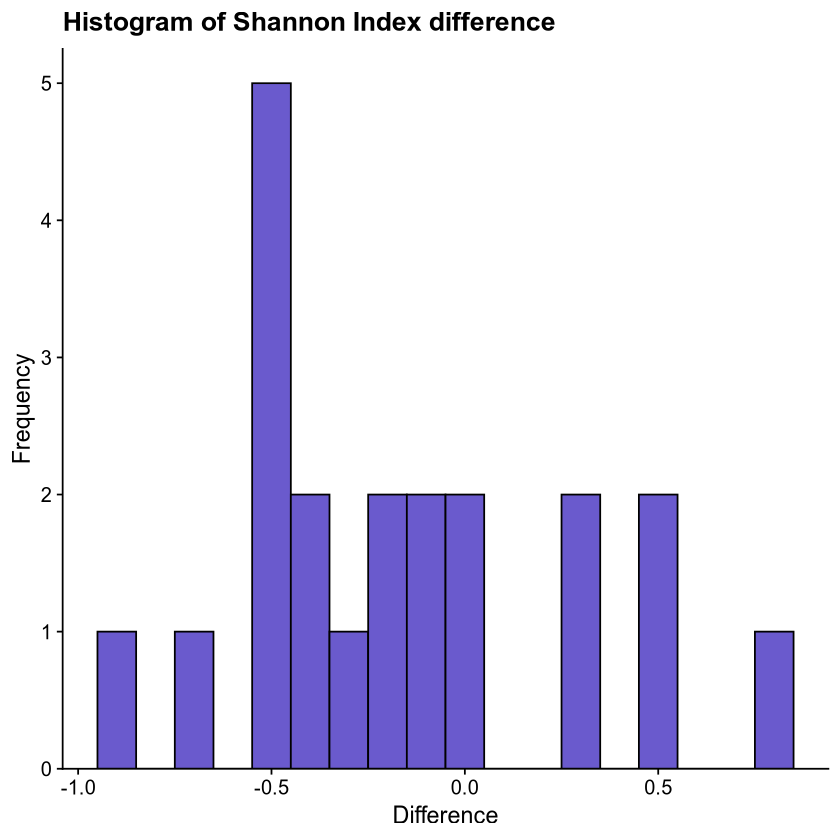

In [31]:
# View the distribution
shannon_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.1, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Shannon Index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [32]:
t.test(Pair(Nulliparous, Primiparous) ~ 1,data = shannon_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 1.804, df = 20, p-value = 0.08632
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.02718631  0.37502272
sample estimates:
mean difference 
      0.1739182 


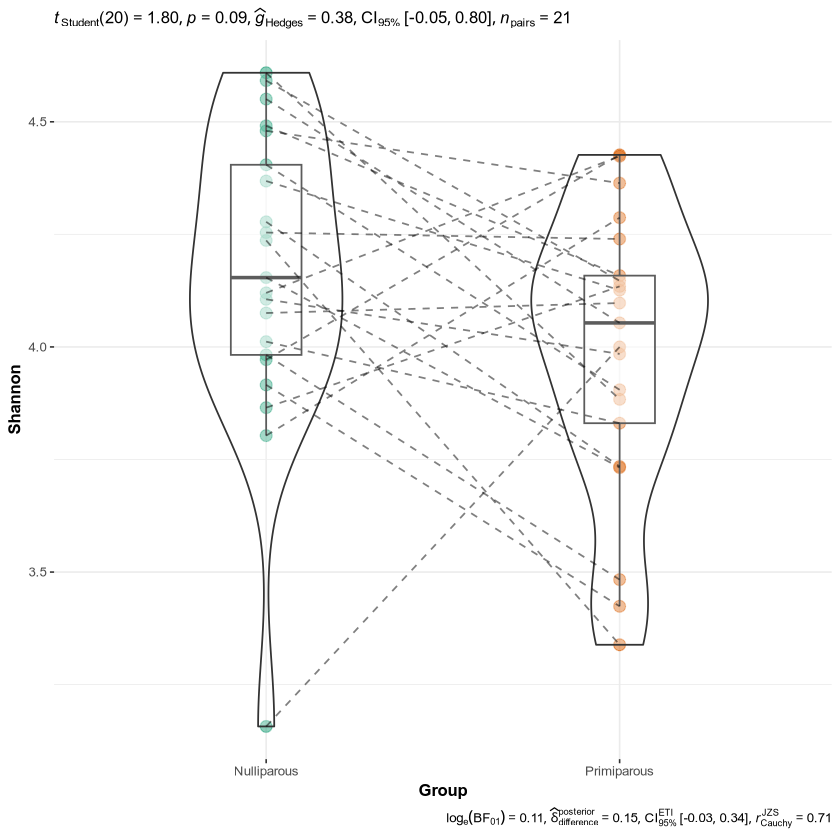

In [33]:
ggwithinstats( # paired samples
  data = df_shannon_1,
  x = Group,
  y = Shannon,
  centrality.plotting = FALSE # remove median
)

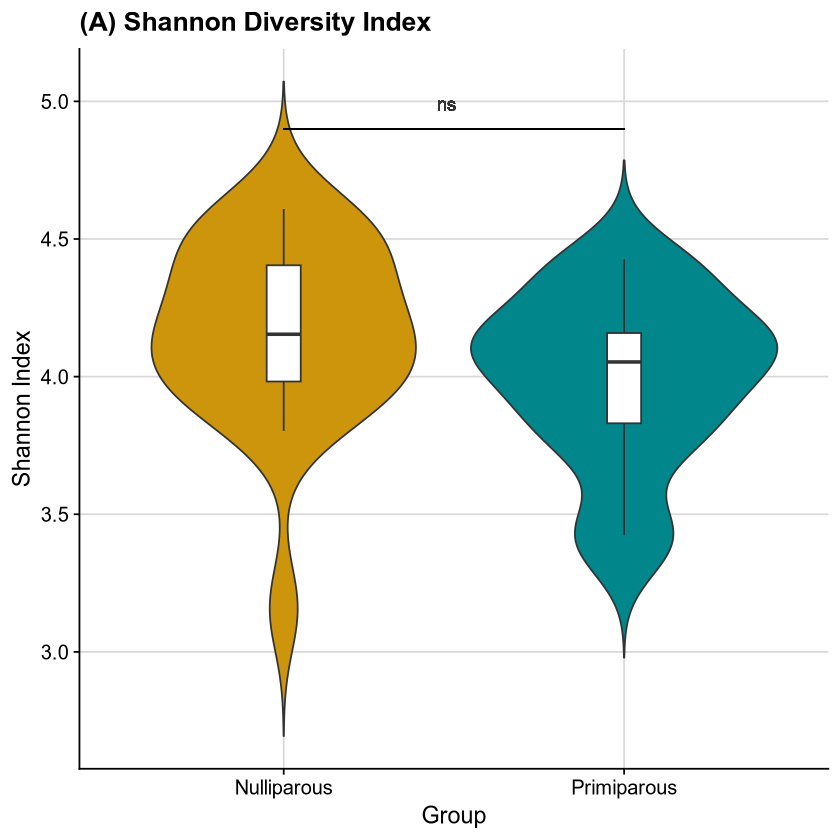

In [34]:
# Shannon Diversity Index Plot
plot_shan <- ggplot(df_shannon, aes(x = Group, y = Shannon, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(title = "(A) Shannon Diversity Index", x = "Group", y = "Shannon Index") +
  theme_half_open() +
  background_grid() +
  geom_text(x = 1.45, y = 4.99, label = "ns", color = "gray20", fontface
            = "plain", hjust = 0) +
  geom_segment(aes(x = 1, xend = 2, y = 4.9, yend = 4.9), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_shan

### Species richness--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [35]:
# Count species num 
# 2 for columns, column = sample
fp_sr <- apply(fp_taxa, 2, specnumber)
head(fp_sr)

100000112243 100000133958 100000168325 100000129494 100000126820 100000123362 
         299          307          311          227          341          274

In [36]:
sp_sr <- apply(sp_taxa, 2, specnumber)
head(sp_sr)

100000418123 100000421192 100000427415 100000426753 100000433799 100000406809 
         151          219          410          389          237          304

In [37]:
summary(fp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  146.0   274.0   327.0   320.3   363.0   415.0 

In [38]:
summary(sp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  151.0   237.0   326.0   310.5   389.0   410.0 

### lpha diversity 

In [39]:
# New df including richness
df_richness <-  data.frame(Species_richness = c(fp_sr, sp_sr), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_sr), length(sp_sr))))
head(df_richness)

,Species_richness,Group
,<int>,<chr>
100000112243,299,Nulliparous
100000133958,307,Nulliparous
100000168325,311,Nulliparous
100000129494,227,Nulliparous
100000126820,341,Nulliparous
100000123362,274,Nulliparous


In [40]:
# Count num of participants
df_richness |> filter(Group == "Nulliparous") |> count()

n
<int>
21


In [41]:
df_richness |> filter(Group == "Primiparous") |> count()

n
<int>
21


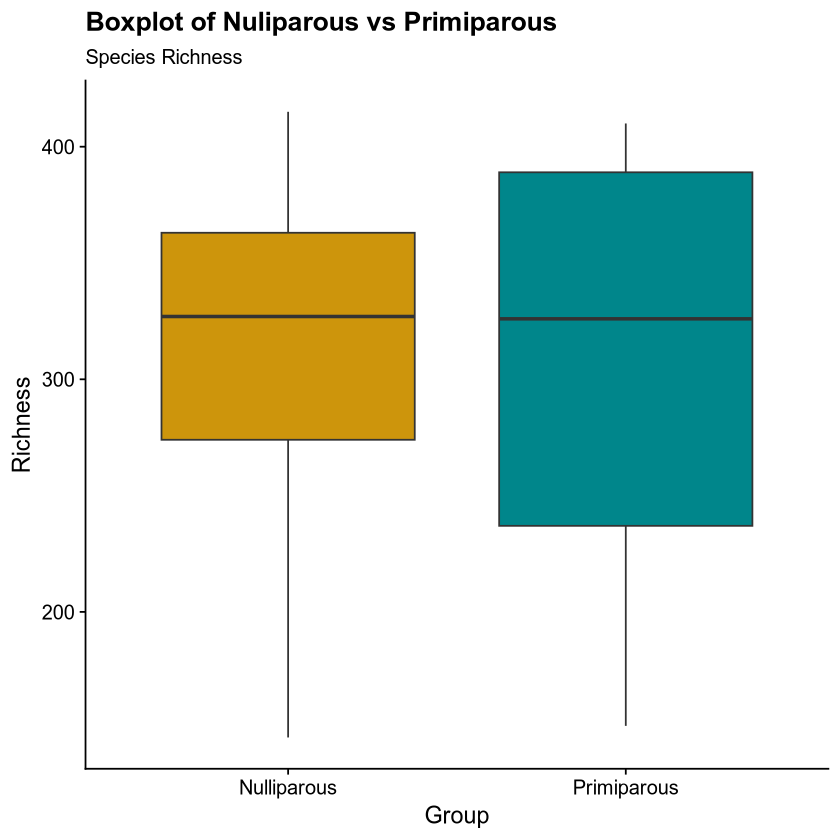

In [42]:
# Boxplot of species richness
df_richness |>
  ggplot(aes(x = Group, y = Species_richness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Richness",
    title = "Boxplot of Nuliparous vs Primiparous",
    subtitle = "Species Richness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") 

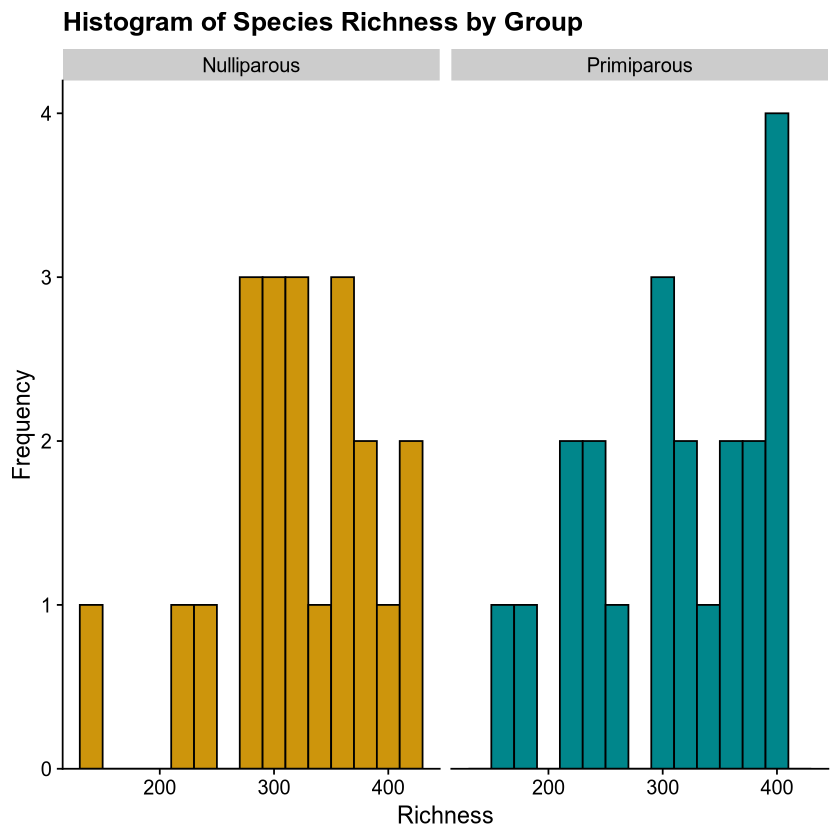

In [43]:
# Histogram of species richness
df_richness |> ggplot(aes(x = Species_richness, fill = Group)) +
  geom_histogram(binwidth = 20, position = "identity", col = "black") +
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Species Richness by Group",
    x = "Richness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [44]:
# Calculate difference for Shapiro test
df_richness_1 <- df_richness |>
  rownames_to_column(var = "Sample_ID")
df_richness_1

Sample_ID,Species_richness,Group
<chr>,<int>,<chr>
100000112243,299,Nulliparous
100000133958,307,Nulliparous
100000168325,311,Nulliparous
100000129494,227,Nulliparous
100000126820,341,Nulliparous
100000123362,274,Nulliparous
100000126714,385,Nulliparous
100000136430,413,Nulliparous
100000140093,407,Nulliparous


In [45]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_richness <- combined_fp_sp_tp2 |>
  filter(kit2.faecal_sample.barcode %in% df_richness_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_richness_1$Personal_number <- pn_richness
df_richness_1$Personal_number

[1] "P159f9c8" "P1a267fa" "P1f862a6" "P3cac7b0" "P3db7da6" "P424fd61"
 [7] "P4a05456" "P4de45e7" "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e"
[13] "P92b4604" "P97574f9" "P9cdfd5a" "Pbe289c8" "Pc44e366" "Pc77a35c"
[19] "Pcd2c0d1" "Pdab1897" "Pe706703" "P159f9c8" "P1a267fa" "P1f862a6"
[25] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P5b98b6c"
[31] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[37] "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897" "Pe706703"

In [46]:
length(df_richness_1$Personal_number)

[1] 42

In [47]:
which(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42

In [48]:
# Write to file, name with no space between, without barcodes
write.csv(df_richness_1, file = paste0("/ceph//projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_richness", ".csv"), row.names = FALSE)

In [49]:
length(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 42

In [50]:
richness_wide <- df_richness_1 |>
  select(Personal_number, Group, Species_richness) |>
  pivot_wider(
             names_from = Group,
             values_from = Species_richness
           )
richness_wide

Personal_number,Nulliparous,Primiparous
<chr>,<int>,<int>
P159f9c8,299,151
P1a267fa,307,219
P1f862a6,311,410
P3cac7b0,227,389
P3db7da6,341,237
P424fd61,274,304
P4a05456,385,328
P4de45e7,413,230
P5b98b6c,407,266


In [51]:
# Test data distribution
richness_wide$difference <- richness_wide$Primiparous - richness_wide$Nulliparous
shapiro.test(richness_wide$difference)


	Shapiro-Wilk normality test

data:  richness_wide$difference
W = 0.97795, p-value = 0.8933


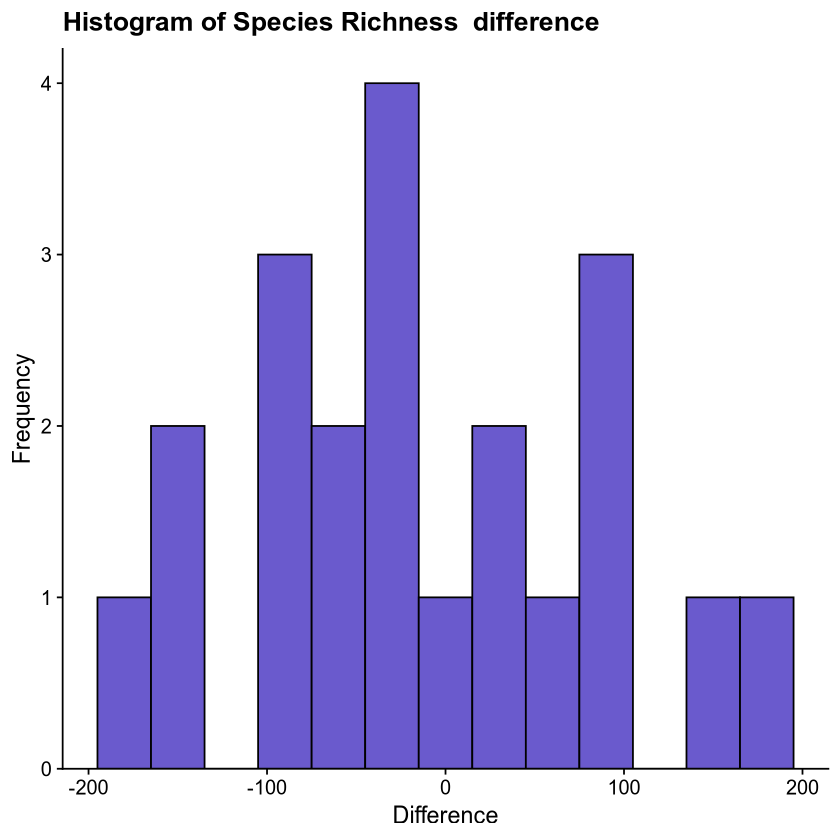

In [52]:
# Data distribution visualization
richness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 30, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Richness  difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [53]:
t.test(Pair(Nulliparous, Primiparous) ~ 1, data = richness_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 0.4382, df = 20, p-value = 0.6659
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -36.88701  56.50605
sample estimates:
mean difference 
       9.809524 


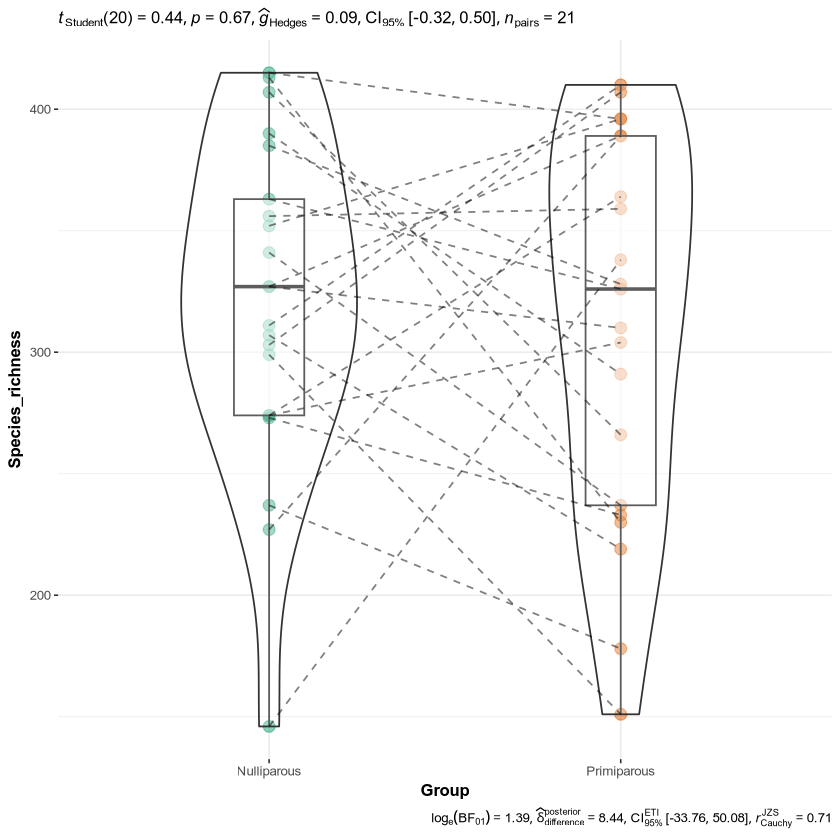

In [54]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_richness,
  x = Group,
  y = Species_richness,
  centrality.plotting = FALSE # remove median
)

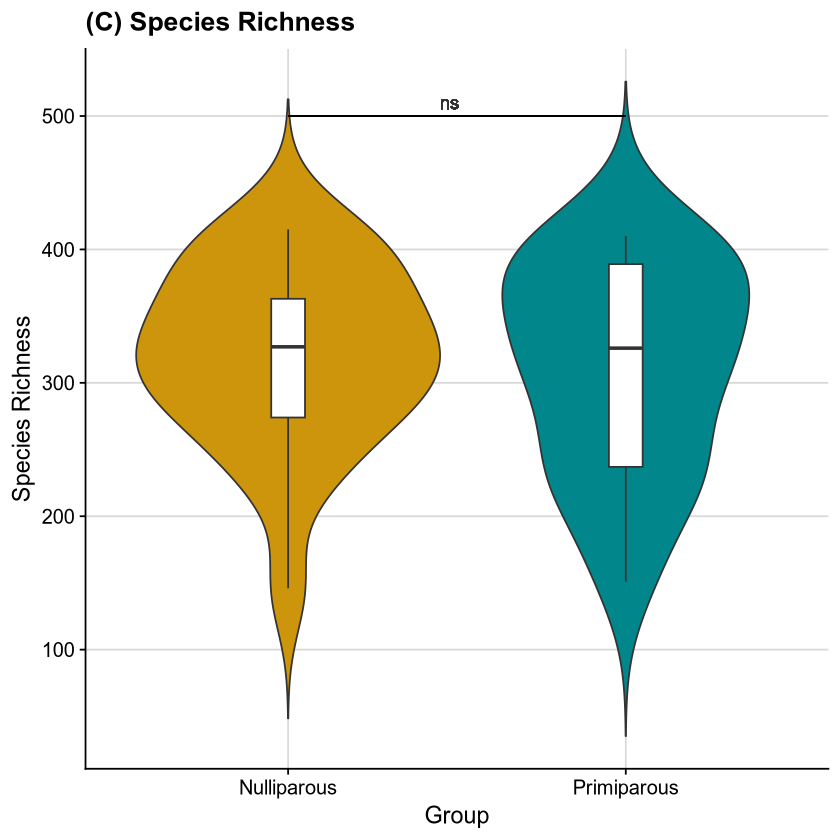

In [55]:
# Shannon Diversity Index Plot
plot_richness <- ggplot(df_richness, aes(x = Group, y = Species_richness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "(C) Species Richness", 
    x = "Group", 
    y = "Species Richness"
    ) +
  theme_half_open() +
  background_grid() +
  geom_text(x = 1.45, y = 510, label = "ns", color = "gray20", fontface
            = "plain", hjust = 0) +
  geom_segment(aes(x = 1, xend = 2, y = 500, yend = 500), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_richness

### Evenness ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [56]:
# Fp
case_pie_small <- fp_shan_tp2/log(fp_sr)
case_pie_small

100000112243 100000133958 100000168325 100000129494 100000126820 100000123362 
   0.7431927    0.7469774    0.6625695    0.7321135    0.6987976    0.7314601 
100000126714 100000136430 100000140093 100000144381 100000155653 100000172865 
   0.7643723    0.7651591    0.7330167    0.7544899    0.7431498    0.7151668 
100000134894 100000172728 100000106303 100000106341 100000103470 100000106136 
   0.7254899    0.7619244    0.6885833    0.7815341    0.7161058    0.7210710 
100000108482 100000148082 100000148693 
   0.6877882    0.6962594    0.6334935

In [57]:
summary(case_pie_small)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6335  0.6988  0.7315  0.7239  0.7470  0.7815 

In [58]:
# Sp
control_pie <- sp_shan_tp2/log(sp_sr)
control_pie

100000418123 100000421192 100000427415 100000426753 100000433799 100000406809 
   0.6653916    0.6929690    0.7125956    0.7422553    0.7493484    0.6969338 
100000417232 100000189313 100000185766 100000408391 100000420362 100000186718 
   0.6996894    0.7141494    0.6993387    0.6918907    0.7295663    0.7027220 
100000426708 100000422069 100000429761 100000434772 100000424926 100000421864 
   0.7088086    0.7185796    0.7010981    0.7048632    0.6607651    0.7361803 
100000426050 100000433645 100000157503 
   0.6071846    0.6578092    0.6869136

In [59]:
summary(control_pie)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6072  0.6919  0.7011  0.6990  0.7141  0.7493 

In [60]:
df_evenness <-  data.frame(Evenness = c(case_pie_small, control_pie), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(case_pie_small), length(control_pie))))
head(df_evenness)
class(df_evenness$Evenness)

,Evenness,Group
,<dbl>,<chr>
100000112243,0.7431927,Nulliparous
100000133958,0.7469774,Nulliparous
100000168325,0.6625695,Nulliparous
100000129494,0.7321135,Nulliparous
100000126820,0.6987976,Nulliparous
100000123362,0.7314601,Nulliparous


[1] "numeric"

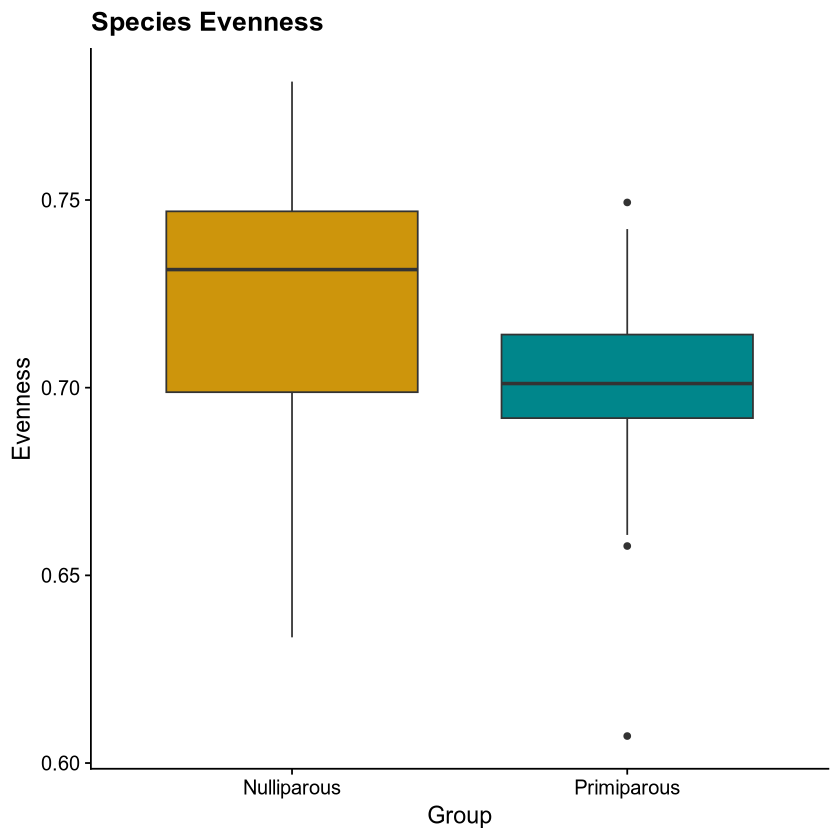

In [61]:
# Boxplot of evenness
 df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Evenness",
    title = "Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

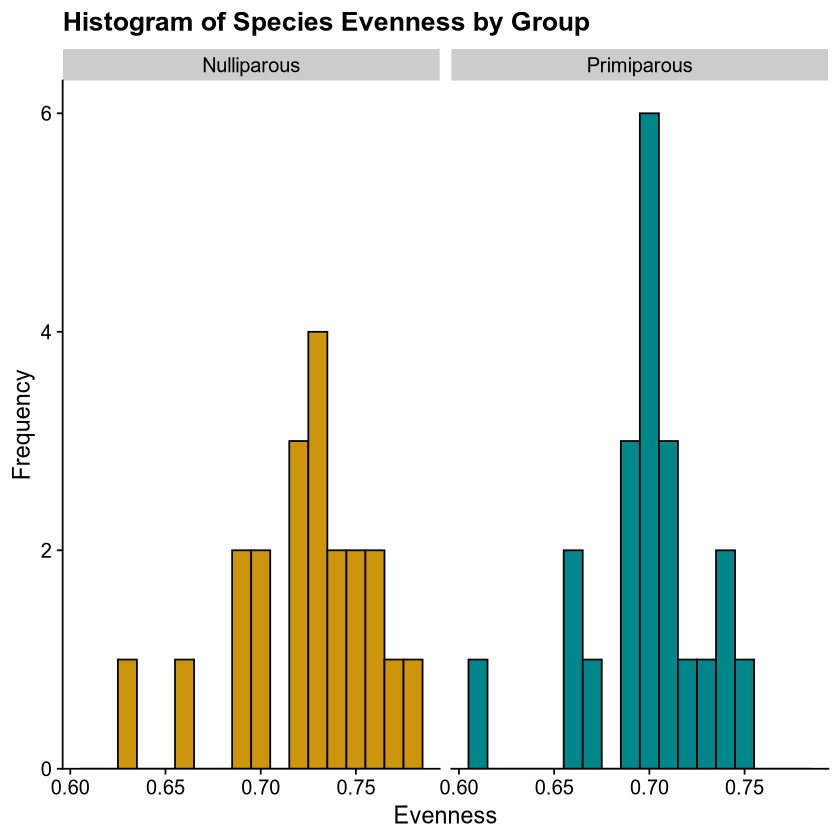

In [62]:
# Histogram of evenness
df_evenness |> ggplot(aes(x = Evenness, fill = Group)) + 
  geom_histogram(binwidth = 0.01, position = "identity", col = "black") + 
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Species Evenness by Group",
    x = "Evenness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [63]:
df_evenness <- df_evenness |>
  rownames_to_column(var = "Sample_ID")
df_evenness

Sample_ID,Evenness,Group
<chr>,<dbl>,<chr>
100000112243,0.7431927,Nulliparous
100000133958,0.7469774,Nulliparous
100000168325,0.6625695,Nulliparous
100000129494,0.7321135,Nulliparous
100000126820,0.6987976,Nulliparous
100000123362,0.7314601,Nulliparous
100000126714,0.7643723,Nulliparous
100000136430,0.7651591,Nulliparous
100000140093,0.7330167,Nulliparous


In [64]:
# Find and extract pn
pn_evenness <- combined_fp_sp_tp2 |>
  filter(kit2.faecal_sample.barcode %in% df_evenness$Sample_ID) |> pull(Q1_Personnummer)
pn_evenness

[1] "P159f9c8" "P1a267fa" "P1f862a6" "P3cac7b0" "P3db7da6" "P424fd61"
 [7] "P4a05456" "P4de45e7" "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e"
[13] "P92b4604" "P97574f9" "P9cdfd5a" "Pbe289c8" "Pc44e366" "Pc77a35c"
[19] "Pcd2c0d1" "Pdab1897" "Pe706703" "P159f9c8" "P1a267fa" "P1f862a6"
[25] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P5b98b6c"
[31] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[37] "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897" "Pe706703"

In [65]:
df_evenness$Personal_number <- pn_evenness
df_evenness

Sample_ID,Evenness,Group,Personal_number
<chr>,<dbl>,<chr>,<chr>
100000112243,0.7431927,Nulliparous,P159f9c8
100000133958,0.7469774,Nulliparous,P1a267fa
100000168325,0.6625695,Nulliparous,P1f862a6
100000129494,0.7321135,Nulliparous,P3cac7b0
100000126820,0.6987976,Nulliparous,P3db7da6
100000123362,0.7314601,Nulliparous,P424fd61
100000126714,0.7643723,Nulliparous,P4a05456
100000136430,0.7651591,Nulliparous,P4de45e7
100000140093,0.7330167,Nulliparous,P5b98b6c


In [66]:
# Write to file, name with no space between, without barcodes
write.csv(df_evenness, file = paste0("/ceph//projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_evenness", ".csv"), row.names = FALSE)

In [67]:
evenness_wide <- df_evenness |>
  select(Personal_number, Group, Evenness) |>
  pivot_wider(
    names_from = Group,
    values_from = Evenness
  )
evenness_wide

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.7431927,0.6653916
P1a267fa,0.7469774,0.6929690
P1f862a6,0.6625695,0.7125956
P3cac7b0,0.7321135,0.7422553
P3db7da6,0.6987976,0.7493484
P424fd61,0.7314601,0.6969338
P4a05456,0.7643723,0.6996894
P4de45e7,0.7651591,0.7141494
P5b98b6c,0.7330167,0.6993387


In [68]:
evenness_wide$difference <- evenness_wide$Primiparous - evenness_wide$Nulliparous
shapiro.test(evenness_wide$difference)


	Shapiro-Wilk normality test

data:  evenness_wide$difference
W = 0.91915, p-value = 0.08345


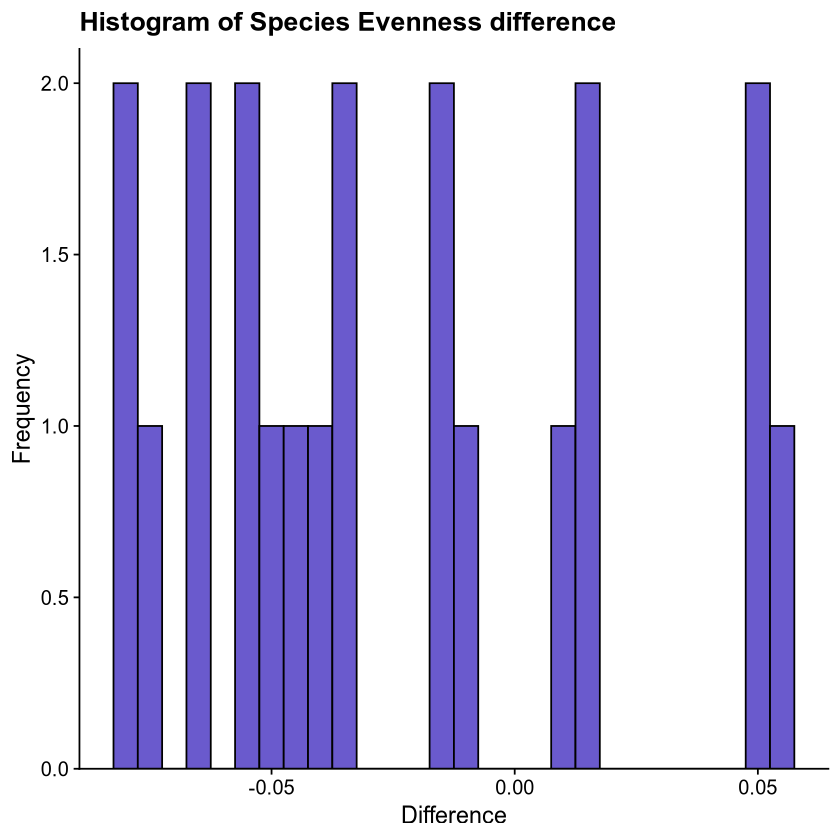

In [69]:
# Visualize data distribution
evenness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.005, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Evenness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

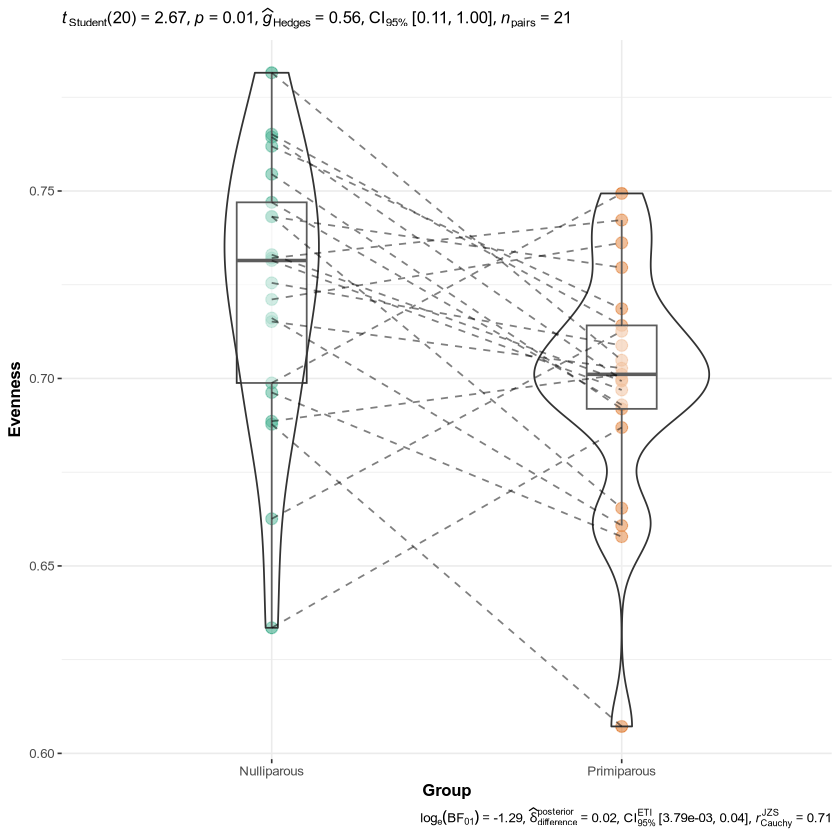

In [69]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_evenness,
  x = Group,
  y = Evenness,
 # type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

In [70]:
# This needs to be checked cause according to the shapiro test data is parametric
test_evenness <- t.test(Pair(Nulliparous, Primiparous) ~1, data = evenness_wide)
test_evenness
evenness_p <- test_evenness$p.value


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 2.6656, df = 20, p-value = 0.01485
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.005422637 0.044449970
sample estimates:
mean difference 
      0.0249363 


In [72]:
evenness_p

[1] 0.01416588

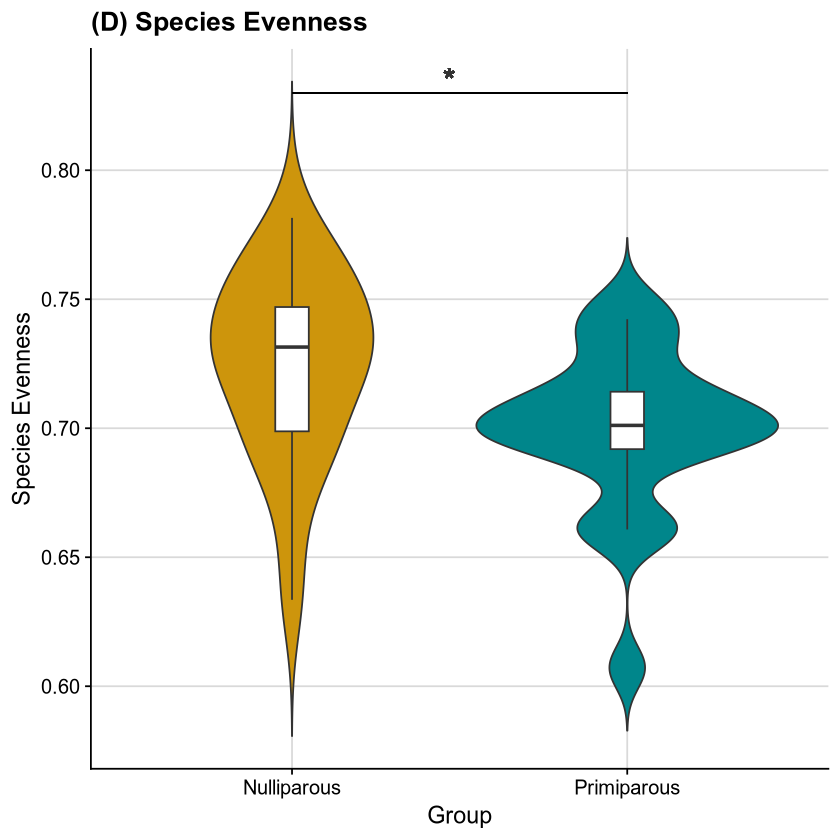

In [71]:
# Violin plots of evenness
plot_evenness <- df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Species Evenness",
    title = "(D) Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  geom_text(x = 1.45, y = 0.835, label = "*", color = "gray20", fontface
            = "plain", hjust = 0, size = 7) +
  geom_segment(aes(x = 1, xend = 2, y = 0.83, yend = 0.83), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_evenness

## Simpson's index---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [74]:
# 2 for columns, column = sample
fp_simpson_tp2 <- apply(fp_taxa, 2, diversity, index = "simpson")
head(fp_simpson_tp2)

100000112243 100000133958 100000168325 100000129494 100000126820 100000123362 
   0.9744463    0.9749388    0.9506192    0.9701793    0.9640417    0.9676004

In [75]:
sp_simpson_tp2 <- apply(sp_taxa, 2, diversity, index = "simpson")
head(sp_simpson_tp2)

100000418123 100000421192 100000427415 100000426753 100000433799 100000406809 
   0.9283836    0.9568614    0.9732170    0.9798593    0.9694476    0.9665725

In [76]:
df_simpson_tp2 <-  data.frame(Simpson = c(fp_simpson_tp2, sp_simpson_tp2), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_simpson_tp2), length(sp_simpson_tp2))))
head(df_simpson_tp2)
class(df_simpson_tp2$Simpson)

,Simpson,Group
,<dbl>,<chr>
100000112243,0.9744463,Nulliparous
100000133958,0.9749388,Nulliparous
100000168325,0.9506192,Nulliparous
100000129494,0.9701793,Nulliparous
100000126820,0.9640417,Nulliparous
100000123362,0.9676004,Nulliparous


[1] "numeric"

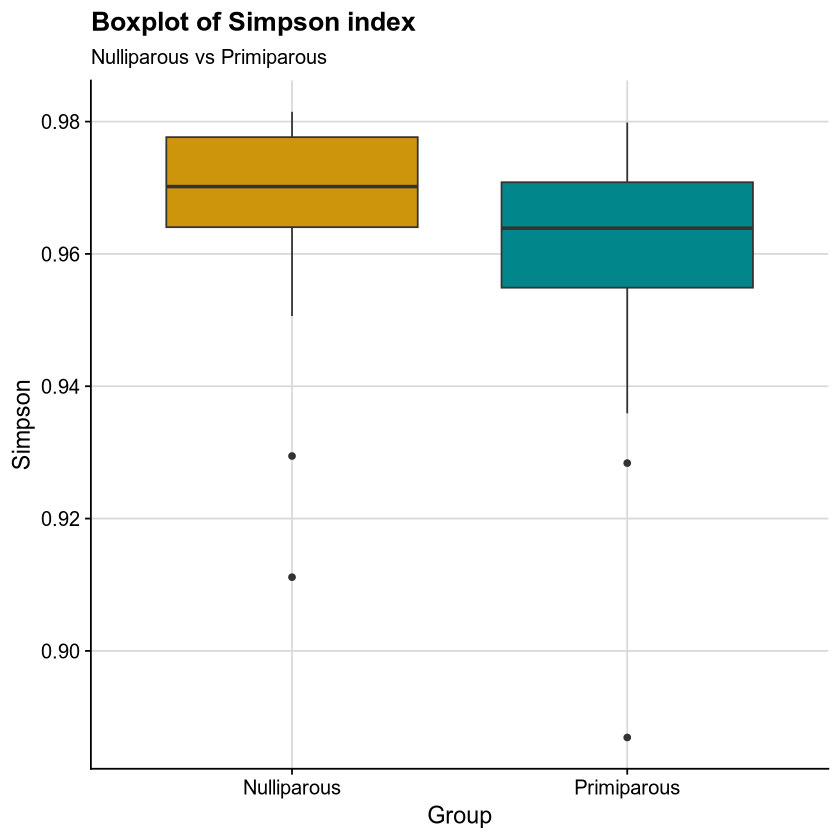

In [77]:
# Boxplot of Simpson index
df_simpson_tp2 |> 
  ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr_tp2) +
  labs(
    title = "Boxplot of Simpson index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Simpson",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

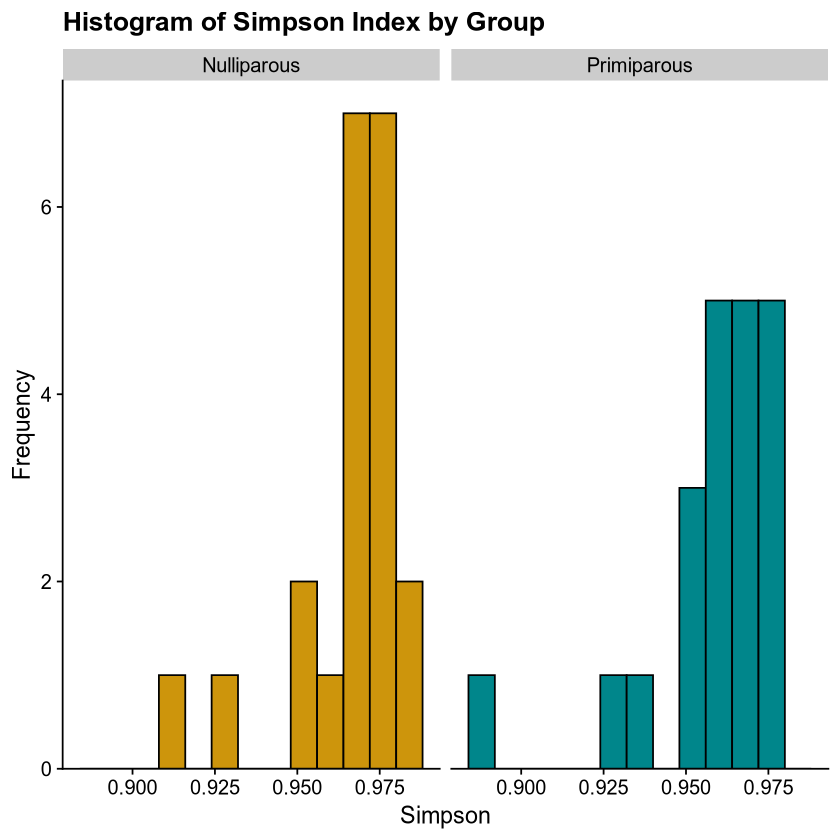

In [78]:
# Histogram of simpson index
df_simpson_tp2 |> ggplot(aes(x = Simpson, fill = Group)) + 
  geom_histogram(binwidth = 0.008, position = "identity", col = "black") + 
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Simpson Index by Group",
    x = "Simpson",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [79]:
df_simpson_1 <- df_simpson_tp2 |>
  rownames_to_column(var = "Sample_ID")
head(df_simpson_1)

,Sample_ID,Simpson,Group
,<chr>,<dbl>,<chr>
1,100000112243,0.9744463,Nulliparous
2,100000133958,0.9749388,Nulliparous
3,100000168325,0.9506192,Nulliparous
4,100000129494,0.9701793,Nulliparous
5,100000126820,0.9640417,Nulliparous
6,100000123362,0.9676004,Nulliparous


In [80]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_simpson <- combined_fp_sp_tp2 |>
  filter(kit2.faecal_sample.barcode %in% df_simpson_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_simpson_1$Personal_number <- pn_simpson
df_simpson_1$Personal_number

[1] "P159f9c8" "P1a267fa" "P1f862a6" "P3cac7b0" "P3db7da6" "P424fd61"
 [7] "P4a05456" "P4de45e7" "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e"
[13] "P92b4604" "P97574f9" "P9cdfd5a" "Pbe289c8" "Pc44e366" "Pc77a35c"
[19] "Pcd2c0d1" "Pdab1897" "Pe706703" "P159f9c8" "P1a267fa" "P1f862a6"
[25] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P5b98b6c"
[31] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[37] "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897" "Pe706703"

In [81]:
length(which(duplicated(df_simpson_1$Personal_number) == TRUE))

[1] 21

In [82]:
write.csv(df_simpson_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/", Sys.Date(), "_tp2_simpson", ".csv"), row.names = FALSE)

In [83]:
simpson_wide <- df_simpson_1 |>
  select(Personal_number, Group, Simpson) |>
  pivot_wider(
             names_from = Group,
             values_from = Simpson
           )
head(simpson_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.9744463,0.9283836
P1a267fa,0.9749388,0.9568614
P1f862a6,0.9506192,0.9732170
P3cac7b0,0.9701793,0.9798593
P3db7da6,0.9640417,0.9694476
P424fd61,0.9676004,0.9665725


In [84]:
# Test data distribution
simpson_wide$difference <- simpson_wide$Primiparous - simpson_wide$Nulliparous
shapiro.test(simpson_wide$difference)


	Shapiro-Wilk normality test

data:  simpson_wide$difference
W = 0.9794, p-value = 0.9165


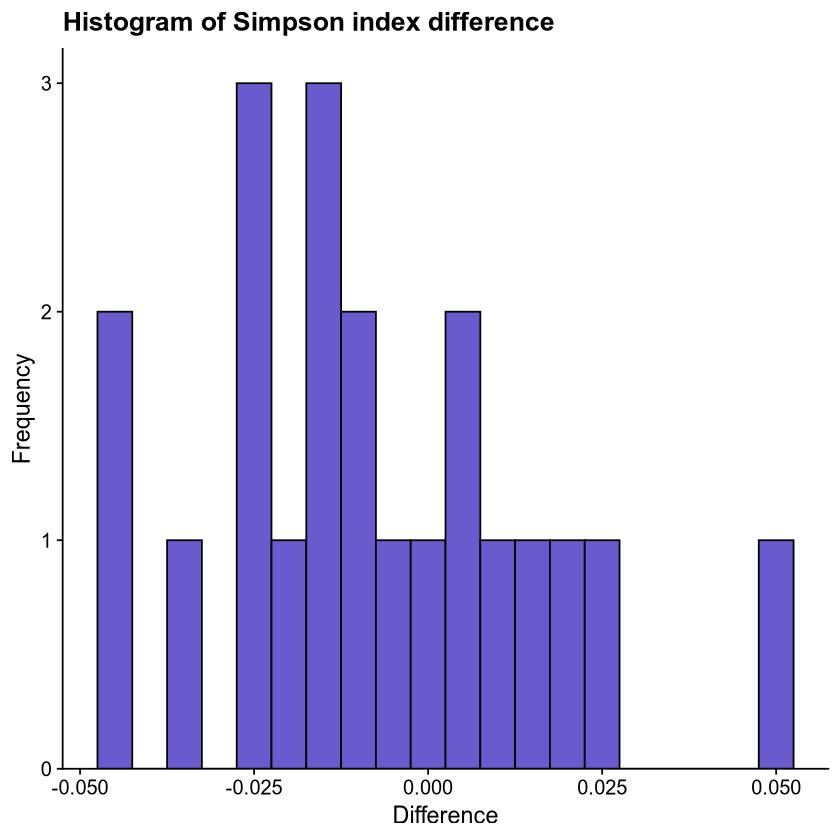

In [85]:
# Data distribution visualization
simpson_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.005, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Simpson index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [86]:
test_simpson <- t.test(Pair(Nulliparous, Primiparous) ~1, data = simpson_wide)
test_simpson


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 1.5369, df = 20, p-value = 0.14
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.00271667  0.01792388
sample estimates:
mean difference 
    0.007603605 


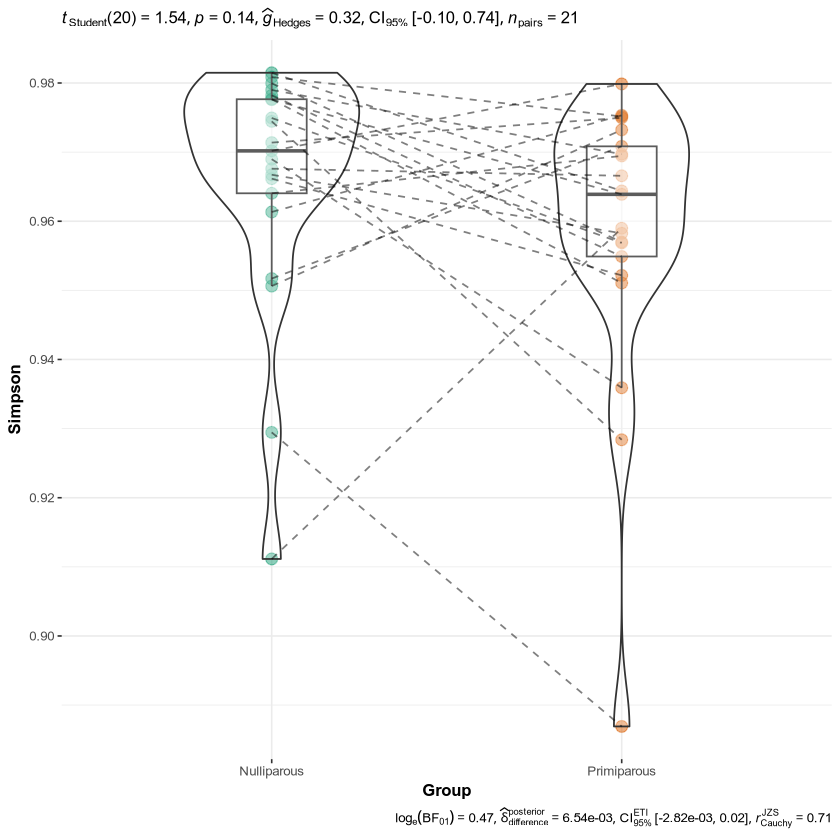

In [87]:
ggwithinstats( # paired samples
  data = df_simpson_1,
  x = Group,
  y = Simpson,
  centrality.plotting = FALSE # remove median
)

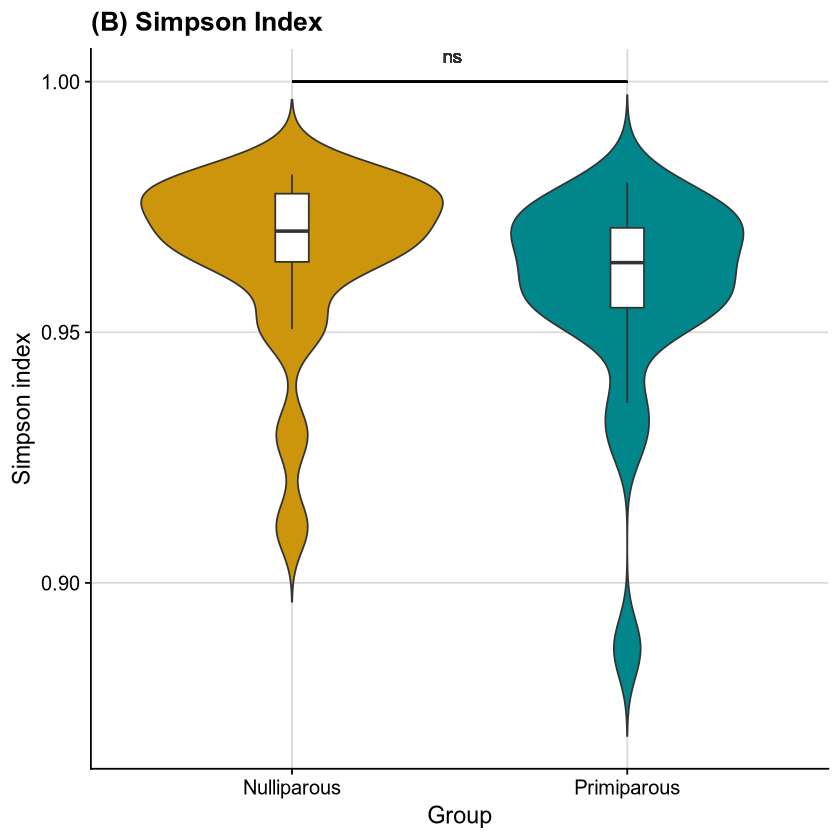

In [92]:
# Violin plots
plot_simpson <- df_simpson_1 |> ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr_tp2) +
  labs(
    x = "Group",
    y = "Simpson index",
    title = "(B) Simpson Index"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  geom_text(x = 1.45, y = 1.005, label = "ns", color = "gray20", fontface
            = "plain", hjust = 0) +
  geom_segment(aes(x = 1, xend = 2, y = 1, yend = 1), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_simpson

# Plots~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

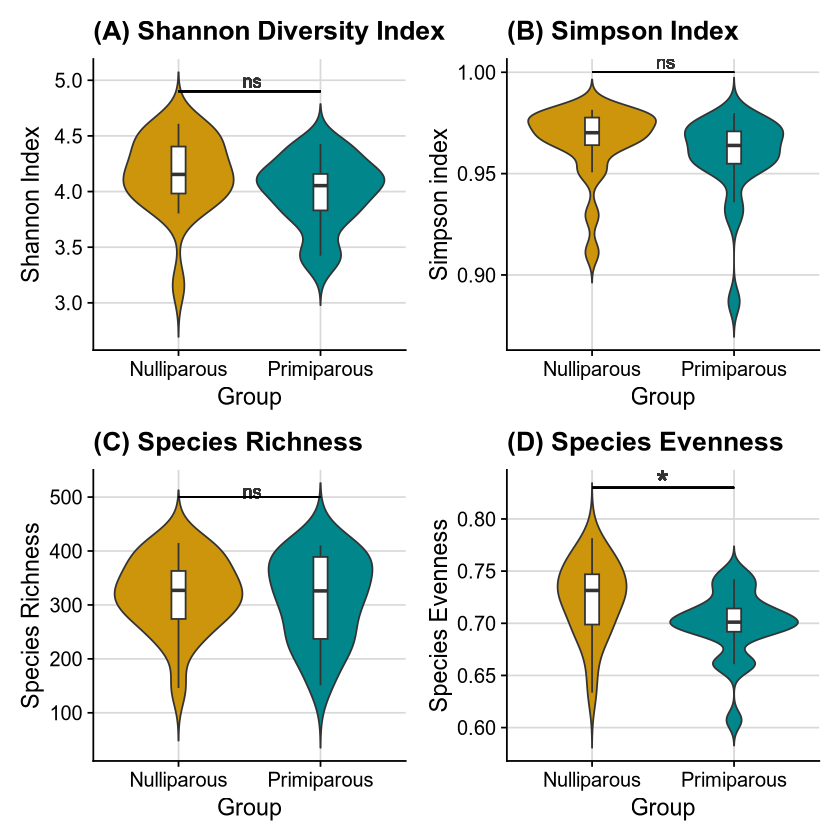

In [97]:
(plot_shan | plot_simpson) / (plot_richness | plot_evenness)